<a href="https://colab.research.google.com/github/SakshiGaikwad22/Car-Resale-Price-Prediction/blob/main/CarResaleEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Libraries

In [ ]:
# Import pandas library for data handling and analysis
import pandas as pd

# Import numpy library for numerical operations
import numpy as np

# Load the CSV dataset into dataframe
df = pd.read_csv("/content/Data.csv")

# Display first 20 rows of dataset
df.head(20)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


## 2. Data Understanding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df.shape

(301, 9)

In [ ]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df["Fuel_Type"].unique()

array(['Petrol', 'Diesel', 'CNG'], dtype=object)

In [ ]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
print(df.head())
print(df.dtypes)



  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object


In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


# Insights

Most vehicles in the dataset are manufactured between 2012





and 2016.



The average selling price is ₹4.66 lakh, indicating dominance of budget and mid-range vehicles.


Luxury vehicles create significant outliers in price-related features.



Higher kilometers driven generally reduce resale value.



Most vehicles are first-owner vehicles, increasing resale trustworthiness.


# 4. Exploratory Data Analysis

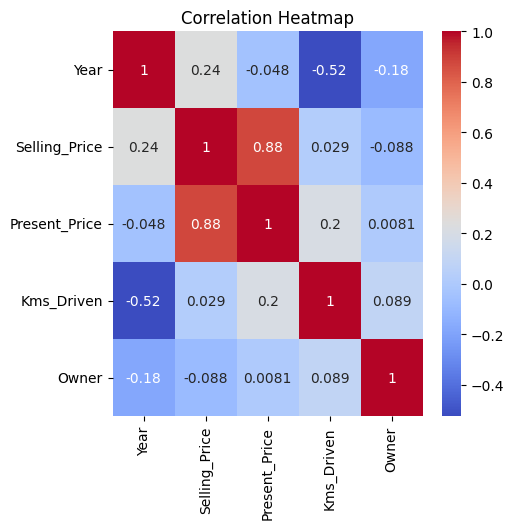

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(5,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 📊 Heatmap Insights

* Present Price and Selling Price have a strong positive correlation (0.88), meaning expensive cars generally have higher resale value.
* Year and Kms Driven show a negative correlation (-0.52), indicating newer vehicles usually have lower mileage.
* Selling Price has weak correlation with Kms Driven and Owner.
* Present Price is the most important factor affecting resale price.


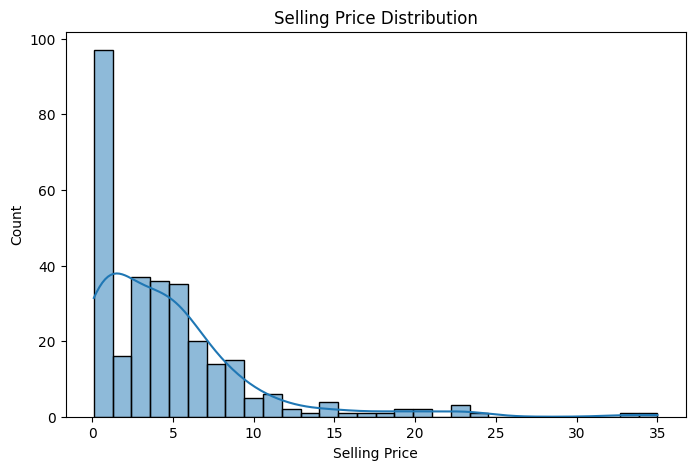

In [ ]:
#Selling Price Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Selling_Price"], bins=30, kde=True)

plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.ylabel("Count")

plt.show()

## 📊 Selling Price Distribution Insights

* Most vehicles have a selling price between ₹0–₹6 lakh, showing that the dataset mainly contains budget and mid-range vehicles.
* The distribution is positively skewed (right-skewed), meaning a few luxury vehicles have very high selling prices.
* Very few vehicles have selling prices above ₹20 lakh, indicating the presence of premium cars as outliers.
* The histogram shows that low-priced vehicles dominate the resale market in this dataset.


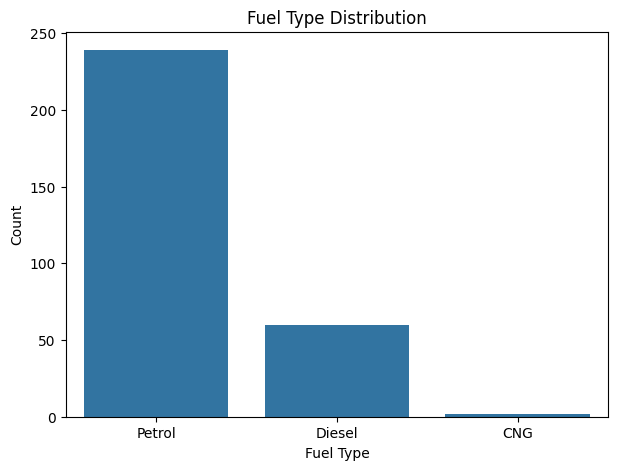

In [ ]:
#Fuel Type Distribution
plt.figure(figsize=(7,5))

sns.countplot(x="Fuel_Type", data=df)

plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")

plt.show()

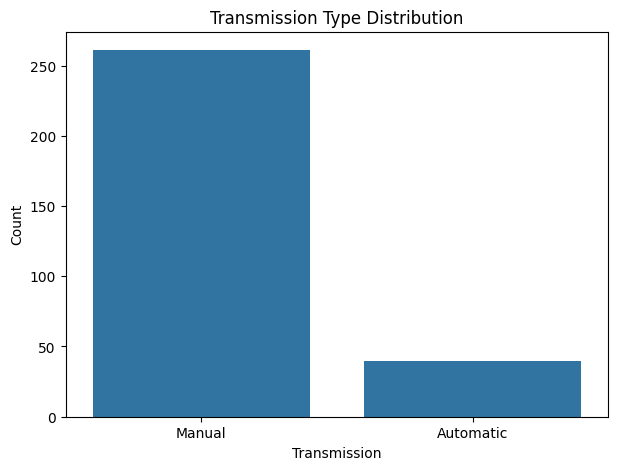

In [ ]:
#Transmission Type Distribution
plt.figure(figsize=(7,5))

sns.countplot(x="Transmission", data=df)

plt.title("Transmission Type Distribution")
plt.xlabel("Transmission")
plt.ylabel("Count")

plt.show()

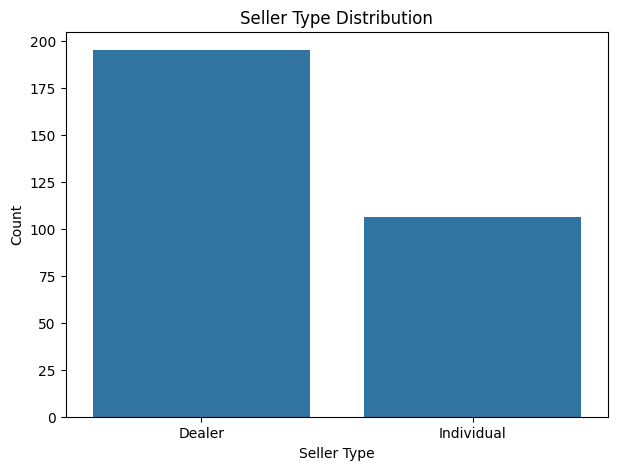

In [ ]:
#Seller Type Distribution
plt.figure(figsize=(7,5))

sns.countplot(x="Seller_Type", data=df)

plt.title("Seller Type Distribution")
plt.xlabel("Seller Type")
plt.ylabel("Count")

plt.show()

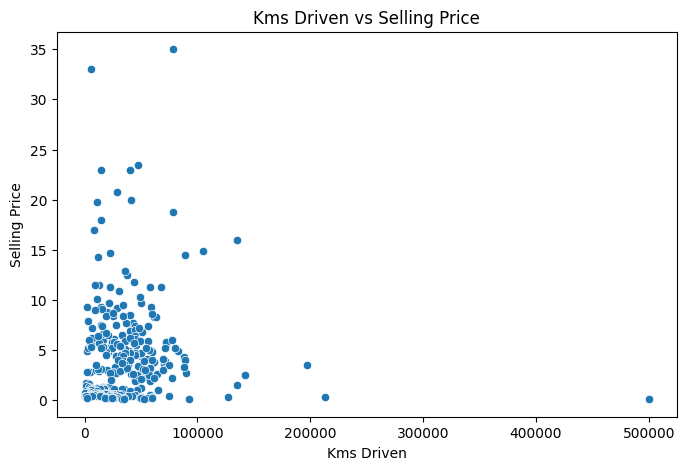

In [ ]:
#Kms Driven vs Selling Price
plt.figure(figsize=(8,5))

sns.scatterplot(x="Kms_Driven", y="Selling_Price", data=df)

plt.title("Kms Driven vs Selling Price")
plt.xlabel("Kms Driven")
plt.ylabel("Selling Price")

plt.show()


Kms Driven↑⇒Selling Price↓

More driven vehicles generally have lower resale value.

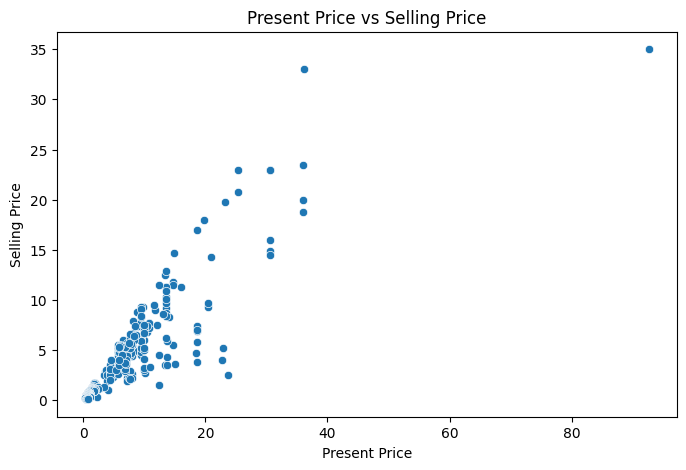

In [ ]:
#Present Price vs Selling Price
plt.figure(figsize=(8,5))

sns.scatterplot(x="Present_Price", y="Selling_Price", data=df)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")

plt.show()

Vehicles with higher showroom price usually have higher resale value.

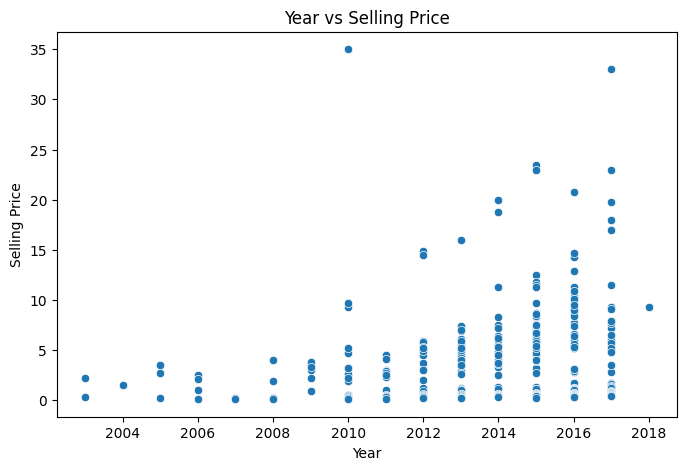

In [ ]:
#Year vs Selling Price
plt.figure(figsize=(8,5))

sns.scatterplot(x="Year", y="Selling_Price", data=df)

plt.title("Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price")

plt.show()


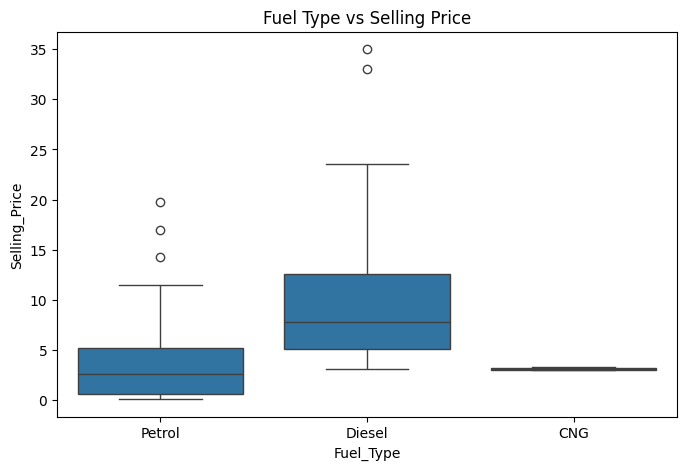

In [ ]:
#Fuel type vs Selling Price
plt.figure(figsize=(8,5))

sns.boxplot(x="Fuel_Type", y="Selling_Price", data=df)

plt.title("Fuel Type vs Selling Price")

plt.show()

## 📊 Fuel Type vs Selling Price Insights

* Diesel vehicles generally have higher selling prices compared to Petrol and CNG vehicles.
* Petrol vehicles show a wider spread in resale prices, indicating presence of both low-budget and premium vehicles.
* CNG vehicles have relatively lower and more consistent selling prices.
* Some Diesel and Petrol vehicles appear as outliers with very high resale prices, representing premium or luxury vehicles.
* Overall, Diesel vehicles dominate the higher resale value segment in the dataset.




# 5. OOP Implementation

Dataset Loaded Successfully
  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64

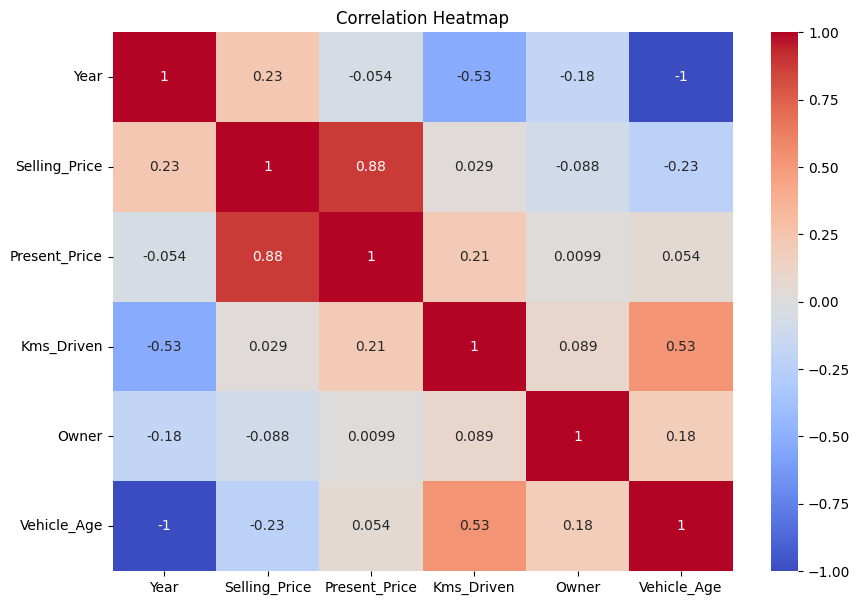

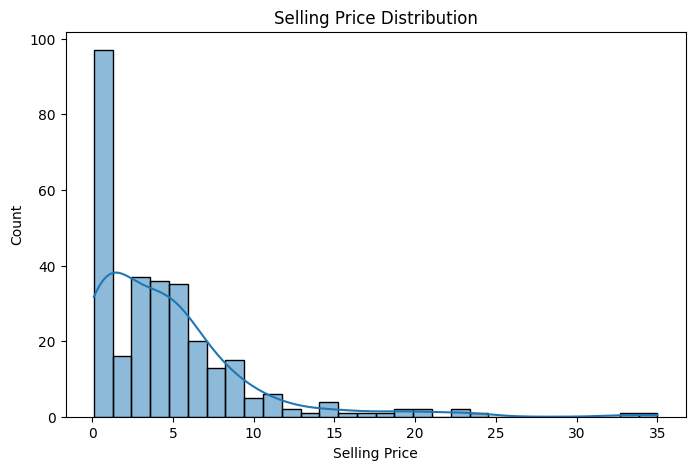

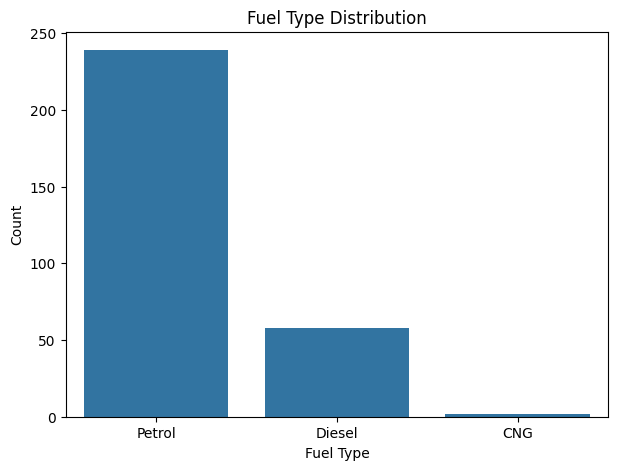

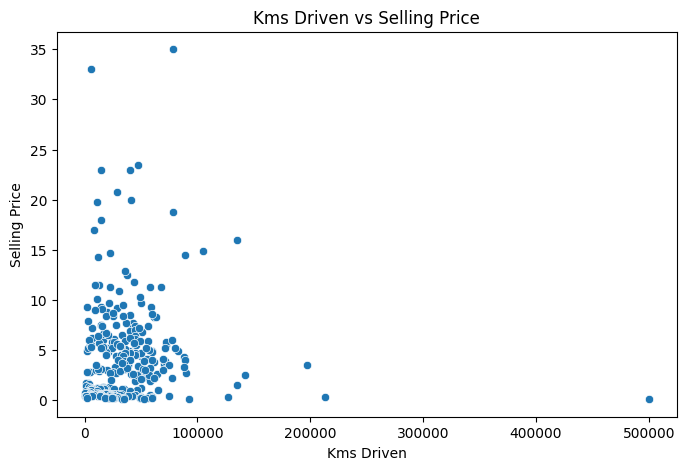

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Create Class
class CarAnalysis:

    # Constructor -> Automatically loads dataset
    def __init__(self, file_path):

        # Load CSV file
        self.df = pd.read_csv(file_path)

        print("Dataset Loaded Successfully")


    # Show first 5 rows of dataset
    def show_data(self):

        print(self.df.head())


    # Show dataset information
    def dataset_info(self):

        print(self.df.info())


    # Show statistical summary
    def statistical_summary(self):

        print(self.df.describe())


    # Data preprocessing method
    def preprocess_data(self):

        # Remove duplicate rows
        self.df.drop_duplicates(inplace=True)

        # Create new column -> Vehicle Age
        self.df["Vehicle_Age"] = 2026 - self.df["Year"]

        print("Preprocessing Completed")


    # Check missing values
    def check_missing_values(self):

        print(self.df.isnull().sum())


    # Correlation Heatmap
    def correlation_heatmap(self):

        # Select only numeric columns
        numeric_df = self.df.select_dtypes(include=['int64', 'float64'])

        # Set figure size
        plt.figure(figsize=(10,7))

        # Create heatmap
        sns.heatmap(numeric_df.corr(),
                    annot=True,
                    cmap='coolwarm')

        # Title
        plt.title("Correlation Heatmap")

        # Show graph
        plt.show()


    # Selling Price Distribution
    def selling_price_distribution(self):

        # Figure size
        plt.figure(figsize=(8,5))

        # Histogram
        sns.histplot(self.df["Selling_Price"],
                     bins=30,
                     kde=True)

        # Graph title
        plt.title("Selling Price Distribution")

        # X-axis label
        plt.xlabel("Selling Price")

        # Y-axis label
        plt.ylabel("Count")

        # Show graph
        plt.show()


    # Fuel Type Distribution
    def fuel_type_distribution(self):

        # Figure size
        plt.figure(figsize=(7,5))

        # Countplot
        sns.countplot(x="Fuel_Type",
                      data=self.df)

        # Graph title
        plt.title("Fuel Type Distribution")

        # X-axis label
        plt.xlabel("Fuel Type")

        # Y-axis label
        plt.ylabel("Count")

        # Show graph
        plt.show()


    # Kms Driven vs Selling Price
    def kms_vs_sellingprice(self):

        # Figure size
        plt.figure(figsize=(8,5))

        # Scatterplot
        sns.scatterplot(x="Kms_Driven",
                        y="Selling_Price",
                        data=self.df)

        # Graph title
        plt.title("Kms Driven vs Selling Price")

        # X-axis label
        plt.xlabel("Kms Driven")

        # Y-axis label
        plt.ylabel("Selling Price")

        # Show graph
        plt.show()


# Create Object
car = CarAnalysis("/content/Data.csv")


# Call Methods
car.show_data()

car.dataset_info()

car.statistical_summary()

car.preprocess_data()

car.check_missing_values()

car.correlation_heatmap()

car.selling_price_distribution()

car.fuel_type_distribution()

car.kms_vs_sellingprice()

# 7.Insights

In [ ]:
class CarAnalysis:

    def __init__(self, file_path):

        self.df = pd.read_csv(file_path)

        print("Dataset Loaded Successfully")


    def show_data(self):

        print(self.df.head())


    def dataset_info(self):

        print(self.df.info())


    def statistical_summary(self):

        print(self.df.describe())


    def preprocess_data(self):

        self.df.drop_duplicates(inplace=True)

        self.df["Vehicle_Age"] = 2026 - self.df["Year"]

        print("Preprocessing Completed")


    def check_missing_values(self):

        print(self.df.isnull().sum())


    def dataset_insights(self):

        avg_price = self.df["Selling_Price"].mean()

        common_fuel = self.df["Fuel_Type"].mode()[0]

        max_price = self.df["Selling_Price"].max()

        min_price = self.df["Selling_Price"].min()

        print("------ Dataset Insights ------")

        print(f"Average Selling Price: {avg_price:.2f} lakh")

        print(f"Most Common Fuel Type: {common_fuel}")

        print(f"Maximum Selling Price: {max_price} lakh")

        print(f"Minimum Selling Price: {min_price} lakh")

In [ ]:
car = CarAnalysis("/content/Data.csv")


Dataset Loaded Successfully


In [ ]:
car.dataset_insights()

------ Dataset Insights ------
Average Selling Price: 4.66 lakh
Most Common Fuel Type: Petrol
Maximum Selling Price: 35.0 lakh
Minimum Selling Price: 0.1 lakh
